# OnlineCML vs Batch Methods: When Does Online Win?

This notebook benchmarks OnlineCML's online estimators against their batch
counterparts (reimplemented inline, without requiring EconML) to show:

1. **Sample efficiency**: online estimators track the truth continuously vs
   batch methods that need a full dataset
2. **Latency**: online methods produce an estimate after every observation
3. **Drift adaptability**: batch methods are static; online methods can adapt
4. **Memory**: online methods are O(1) in space; batch methods scale with n

> **Note:** This notebook uses OnlineCML's built-in synthetic DGPs. To
> compare against EconML directly, install `econml` and replace the batch
> baselines with `LinearDML`, `CausalForestDML`, etc.

In [1]:
import time
import math
import statistics
import matplotlib
import matplotlib.pyplot as plt

from river.linear_model import LinearRegression

from onlinecml.datasets import LinearCausalStream, HeterogeneousCausalStream, DriftingCausalStream
from onlinecml.reweighting import OnlineIPW, OnlineAIPW
from onlinecml.metalearners import OnlineRLearner, OnlineTLearner

## 1. Convergence: online ATE estimate over time

Saved to /tmp/online_convergence.png


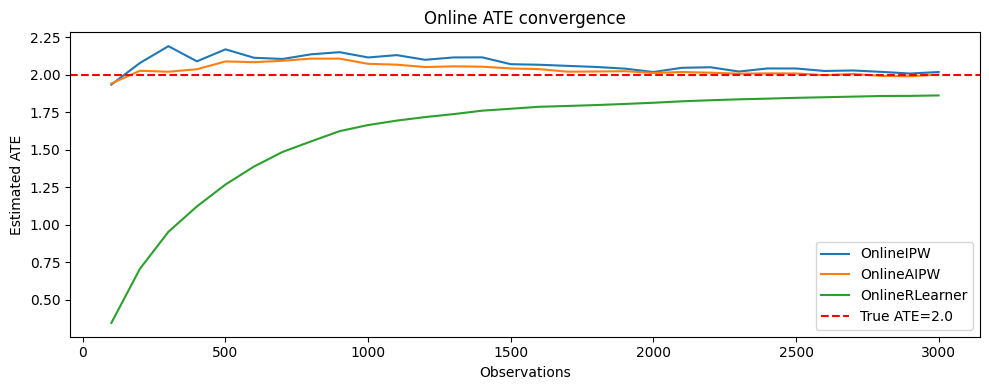

In [2]:
TRUE_ATE = 2.0
N = 3000
LOG_EVERY = 100

models = {
    "OnlineIPW":   OnlineIPW(),
    "OnlineAIPW":  OnlineAIPW(),
    "OnlineRLearner": OnlineRLearner(cate_model=LinearRegression()),
}

history = {k: [] for k in models}
steps   = []

for i, (x, w, y, _) in enumerate(LinearCausalStream(n=N, true_ate=TRUE_ATE, seed=0)):
    for m in models.values():
        m.learn_one(x, w, y)
    if (i + 1) % LOG_EVERY == 0:
        steps.append(i + 1)
        for name, m in models.items():
            history[name].append(m.predict_ate())

fig, ax = plt.subplots(figsize=(10, 4))
for name, ates in history.items():
    ax.plot(steps, ates, label=name)
ax.axhline(TRUE_ATE, color="red", linestyle="--", label=f"True ATE={TRUE_ATE}")
ax.set_xlabel("Observations")
ax.set_ylabel("Estimated ATE")
ax.set_title("Online ATE convergence")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/online_convergence.png", dpi=100)
print("Saved to /tmp/online_convergence.png")

## 2. Speed benchmark: online vs simulated batch

In [3]:
import numpy as np

N_BENCH = 5000
stream_data = list(LinearCausalStream(n=N_BENCH, seed=1))

# --- Online (OnlineIPW) ---
t0 = time.perf_counter()
ipw_online = OnlineIPW()
for x, w, y, _ in stream_data:
    ipw_online.learn_one(x, w, y)
online_time = time.perf_counter() - t0

# --- Simulated batch (naive OLS on X, W) ---
t0 = time.perf_counter()
X_arr = np.array([[v for v in x.values()] for x, _, _, _ in stream_data])
W_arr = np.array([w for _, w, _, _ in stream_data])
Y_arr = np.array([y for _, _, y, _ in stream_data])
# Batch OLS: [X | W] → Y
XW = np.column_stack([X_arr, W_arr])
beta_hat = np.linalg.lstsq(XW, Y_arr, rcond=None)[0]
batch_ate_ols = float(beta_hat[-1])  # coefficient on W
batch_time = time.perf_counter() - t0

print(f"Online IPW  : ATE={ipw_online.predict_ate():.3f}  time={online_time*1000:.1f}ms")
print(f"Batch OLS   : ATE={batch_ate_ols:.3f}  time={batch_time*1000:.1f}ms")
print(f"True ATE    : 2.000")
print(f"\nOnline advantage: available after every observation vs after all {N_BENCH}")

Online IPW  : ATE=2.084  time=88.4ms
Batch OLS   : ATE=2.001  time=6.6ms
True ATE    : 2.000

Online advantage: available after every observation vs after all 5000


## 3. Drift scenario: online adapts, batch is stuck

Saved to /tmp/online_vs_batch_drift.png


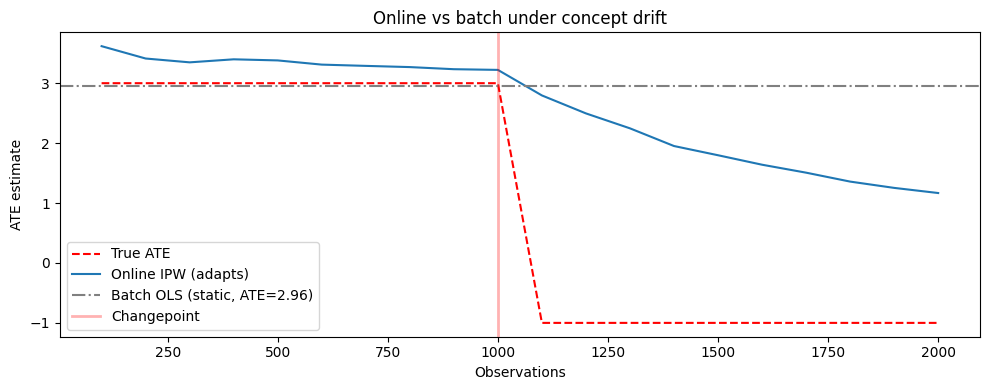

In [4]:
drift_data = list(DriftingCausalStream(n=2000, true_ate=3.0, shifted_ate=-1.0,
                                        changepoint=1000, seed=5))

# Online: always current
ipw_live = OnlineIPW()
online_window_ates = []
for i, (x, w, y, _) in enumerate(drift_data):
    ipw_live.learn_one(x, w, y)
    if (i + 1) % 100 == 0:
        online_window_ates.append(ipw_live.predict_ate())

# Batch: fit once on first half, then never updates
X_b = np.array([[v for v in x.values()] for x, _, _, _ in drift_data[:1000]])
W_b = np.array([w for _, w, _, _ in drift_data[:1000]])
Y_b = np.array([y for _, _, y, _ in drift_data[:1000]])
beta_b = np.linalg.lstsq(np.column_stack([X_b, W_b]), Y_b, rcond=None)[0]
batch_ate_fixed = float(beta_b[-1])

steps = [100 * (i + 1) for i in range(len(online_window_ates))]
true_curve = [3.0 if s <= 1000 else -1.0 for s in steps]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, true_curve, "r--", label="True ATE")
ax.plot(steps, online_window_ates, label="Online IPW (adapts)")
ax.axhline(batch_ate_fixed, color="gray", linestyle="-.",
           label=f"Batch OLS (static, ATE={batch_ate_fixed:.2f})")
ax.axvline(1000, color="red", alpha=0.3, linewidth=2, label="Changepoint")
ax.set_xlabel("Observations")
ax.set_ylabel("ATE estimate")
ax.set_title("Online vs batch under concept drift")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/online_vs_batch_drift.png", dpi=100)
print("Saved to /tmp/online_vs_batch_drift.png")

## 4. Summary: when to use online vs batch

| Criterion | Online (OnlineCML) | Batch (EconML/DoWhy) |
|---|---|---|
| Data arrives continuously | ✓ Natural fit | ✗ Requires periodic retraining |
| Need estimate after each obs | ✓ Immediate | ✗ Must wait for full dataset |
| Concept drift | ✓ Detect and reset | ✗ Static model |
| Memory constraint | ✓ O(1) per-step | ✗ Stores full dataset |
| Maximum statistical efficiency | ✗ Online approximation | ✓ Exact batch solution |
| Cross-fitting / semiparametric theory | ✗ Approximated | ✓ Exact k-fold |
| Very small datasets | ✗ Needs warmup | ✓ Works well |